In [1]:
import os
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, classification_report,
    f1_score, accuracy_score, roc_curve, auc
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
import itertools


In [2]:
def flux_to_class(flux, only_main=False):
    """Convert GOES flux to flare class (A/B/C/M/X)."""
    if isinstance(flux, str):
        flux = float(flux.replace("e", "E"))
    if flux < 1e-7:
        return 'A' if only_main else 'A (<1e-7)'
    elif flux < 1e-6:
        return 'B' if only_main else 'B (1e-7–1e-6)'
    elif flux < 1e-5:
        return 'C' if only_main else 'C (1e-6–1e-5)'
    elif flux < 1e-4:
        return 'M' if only_main else 'M (1e-5–1e-4)'
    else:
        return 'X' if only_main else 'X (>1e-4)'


In [3]:
def create_simple_image_set(base_path, balance=True):
    """
    Loads and preprocesses images (28×28 grayscale).
    Returns balanced dataset (equal flare / non-flare if balance=True).
    """
    meta_csv = os.path.join(base_path, 'meta_data.csv')
    df = pd.read_csv(meta_csv, parse_dates=["start", "end"], index_col="id")

    images, labels = [], []

    for row_id, row in df.iterrows():
        ar_nr, p = row_id.split("_", 1)
        img_path = os.path.join(base_path, ar_nr, p)
        if not os.path.isdir(img_path):
            continue

        for img_name in os.listdir(img_path):
            if img_name.endswith('_magnetogram.jpg'):
                im = Image.open(os.path.join(img_path, img_name)).convert('L')
                im = im.crop((44, 44, 212, 212))
                im = im.resize((28, 28), Image.Resampling.LANCZOS)
                im = np.array(im) / 255.0
                label = int(flux_to_class(row['peak_flux'], only_main=True) in ['M', 'X'])
                images.append(im.flatten())   # flatten for scikit-learn
                labels.append(label)

    X, Y = np.array(images), np.array(labels)

    if balance:
        flare_idx = np.where(Y == 1)[0]
        nonflare_idx = np.where(Y == 0)[0]
        np.random.shuffle(nonflare_idx)
        nonflare_idx = nonflare_idx[:len(flare_idx)]
        idx = np.concatenate([flare_idx, nonflare_idx])
        np.random.shuffle(idx)
        X, Y = X[idx], Y[idx]

    return X, Y

# Load data
base_train = "/Users/yashvisingh/Documents/sunpy/data/github_data/SDOBenchmark_full/training"
base_test  = "/Users/yashvisingh/Documents/sunpy/data/github_data/SDOBenchmark_full/test"

X_train, Y_train = create_simple_image_set(base_train)
X_test,  Y_test  = create_simple_image_set(base_test)

print(f"Train: {X_train.shape},  Test: {X_test.shape}")


Train: (4050, 784),  Test: (1360, 784)


In [5]:
# ---- Cell: Check Balance of Dataset ----
import numpy as np

def check_balance(Y_train, Y_test):
    unique_train, counts_train = np.unique(Y_train, return_counts=True)
    unique_test, counts_test = np.unique(Y_test, return_counts=True)

    print("Training label distribution:")
    for label, count in zip(unique_train, counts_train):
        print(f"  Label {label}: {count} samples")

    print("\nTesting label distribution:")
    for label, count in zip(unique_test, counts_test):
        print(f"  Label {label}: {count} samples")

    # Optional quick ratio check
    print("\nTrain ratio (flare/non-flare):", counts_train[1] / counts_train[0] if len(counts_train) > 1 else "N/A")
    print("Test ratio (flare/non-flare):", counts_test[1] / counts_test[0] if len(counts_test) > 1 else "N/A")

# Call this after creating datasets
check_balance(Y_train, Y_test)


Training label distribution:
  Label 0: 2025 samples
  Label 1: 2025 samples

Testing label distribution:
  Label 0: 680 samples
  Label 1: 680 samples

Train ratio (flare/non-flare): 1.0
Test ratio (flare/non-flare): 1.0


In [4]:
knn = KNeighborsClassifier(n_neighbors=5, weights='distance', n_jobs=-1)
knn.fit(X_train, Y_train)
print(" K-Nearest Neighbors training completed!")


 K-Nearest Neighbors training completed!


 Accuracy: 0.5529
 F1 Score: 0.2830

Classification Report:
              precision    recall  f1-score   support

   Non-Flare       0.53      0.93      0.68       680
       Flare       0.71      0.18      0.28       680

    accuracy                           0.55      1360
   macro avg       0.62      0.55      0.48      1360
weighted avg       0.62      0.55      0.48      1360



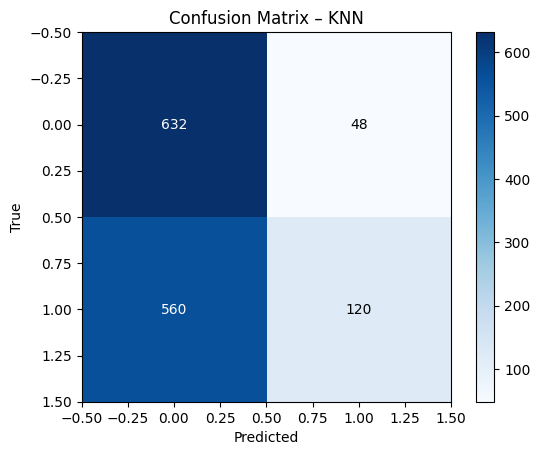

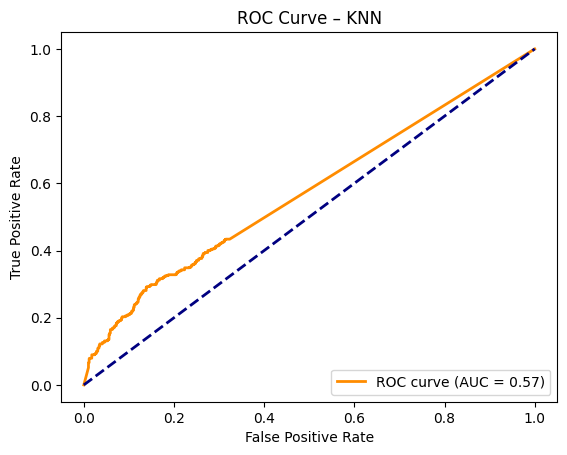

True Skill Statistic (TSS): 0.1059


In [6]:
# ---- Predictions ----
Y_pred = knn.predict(X_test)
Y_prob = knn.predict_proba(X_test)[:, 1]

# ---- Metrics ----
acc = accuracy_score(Y_test, Y_pred)
f1  = f1_score(Y_test, Y_pred)
print(f" Accuracy: {acc:.4f}")
print(f" F1 Score: {f1:.4f}\n")

print("Classification Report:")
print(classification_report(Y_test, Y_pred, target_names=["Non-Flare", "Flare"]))

# ---- Confusion Matrix ----
cm = confusion_matrix(Y_test, Y_pred)
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix – KNN")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, cm[i, j], ha="center", va="center",
             color="white" if cm[i, j] > cm.max()/2 else "black")
plt.show()

# ---- ROC Curve ----
fpr, tpr, _ = roc_curve(Y_test, Y_prob)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0,1],[0,1],'--', color='navy', lw=2)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – KNN')
plt.legend(loc="lower right")
plt.show()

# ---- True Skill Statistic (TSS) ----
tn, fp, fn, tp = cm.ravel()
TSS = tp / (tp + fn) - fp / (fp + tn)
print(f"True Skill Statistic (TSS): {TSS:.4f}")
